In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
import torch
print(torch.cuda.is_available())

True


In [10]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [11]:
import os
print(os.listdir("/kaggle/input/datasets"))

['vipoooool']


In [12]:
print(os.listdir("/kaggle/input/datasets/vipoooool"))

['new-plant-diseases-dataset']


In [13]:
train_dir = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/train"
test_dir = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test"

In [14]:
train_dir

'/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/train'

In [15]:
test_dir

'/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test'

In [17]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,GlobalAveragePooling2D , Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

In [18]:
conv_base = MobileNetV2(weights = 'imagenet',include_top = False , input_shape = (224,224,3))

conv_base.trainable = False

I0000 00:00:1774780559.808396      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774780559.814369      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

batch_size = 32

# -------------------------------
# Data augmentation for training
# -------------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.3,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# -------------------------------
# Validation / test (no augmentation)
# -------------------------------
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# -------------------------------
# Train generator
# -------------------------------
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',  # folder containing class folders
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',   # categorical because you have >2 classes
    shuffle=True,
    seed=42
)

# -------------------------------
# Validation generator
# -------------------------------
validation_generator = test_datagen.flow_from_directory(
    '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',   # folder containing class folders
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',   # same here
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [28]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [29]:

model = Sequential([
    conv_base,
    GlobalAveragePooling2D(),  # better than Flatten
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(38, activation='softmax')  # binary classification
])

In [30]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [32]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator,callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1774780926.602294     186 service.cc:152] XLA service 0x7da2d0113660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774780926.602330     186 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774780926.602338     186 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774780927.891636     186 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-29 10:42:17.405732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 10:42:17.542889: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1774780939.966665     186 device_co

 464/2197 ━━━━━━━━━━━━━━━━━━━━ 17:52 619ms/step - accuracy: 0.0434 - loss: 3.9315

2026-03-29 10:47:16.265443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 10:47:16.402727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.0964 - loss: 3.5524

2026-03-29 11:07:30.196403: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:07:30.335596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1532s 689ms/step - accuracy: 0.0964 - loss: 3.5522 - val_accuracy: 0.4786 - val_loss: 2.4100
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 949s 432ms/step - accuracy: 0.3564 - loss: 2.4214 - val_accuracy: 0.6711 - val_loss: 1.6056
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 943s 429ms/step - accuracy: 0.5094 - loss: 1.7956 - val_accuracy: 0.7495 - val_loss: 1.1925
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 924s 420ms/step - accuracy: 0.5933 - loss: 1.4557 - val_accuracy: 0.7864 - val_loss: 0.9631
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 942s 429ms/step - accuracy: 0.6513 - loss: 1.2268 - val_accuracy: 0.8116 - val_loss: 0.8147
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 912s 415ms/step - accuracy: 0.6913 - loss: 1.0799 - val_accuracy: 0.8269 - val_loss: 0.7184
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 954s 434ms/step - accuracy: 0.7150 - loss: 0.9823 - val_accuracy: 0.8416 - val_loss: 0.6428
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 957s 436ms/step - accuracy: 0.

In [34]:
conv_base.trainable = True

# freeze most layers, train last few
for layer in conv_base.layers[:-30]:
    layer.trainable = False

In [35]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 🔥 very important
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 937s 419ms/step - accuracy: 0.7138 - loss: 0.9765 - val_accuracy: 0.9140 - val_loss: 0.2817
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 920s 419ms/step - accuracy: 0.8575 - loss: 0.4627 - val_accuracy: 0.9400 - val_loss: 0.1991
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 965s 439ms/step - accuracy: 0.8922 - loss: 0.3490 - val_accuracy: 0.9508 - val_loss: 0.1586
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 892s 406ms/step - accuracy: 0.9088 - loss: 0.2877 - val_accuracy: 0.9571 - val_loss: 0.1396
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 910s 414ms/step - accuracy: 0.9257 - loss: 0.2364 - val_accuracy: 0.9616 - val_loss: 0.1221
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 936s 426ms/step - accuracy: 0.9352 - loss: 0.2037 - val_accuracy: 0.9658 - val_loss: 0.1055
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 925s 421ms/step - accuracy: 0.9448 - loss: 0.1788 - val_accuracy: 0.9653 - val_loss: 0.1057
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 970s 441ms/step - ac

In [38]:
import matplotlib.pyplot as plt

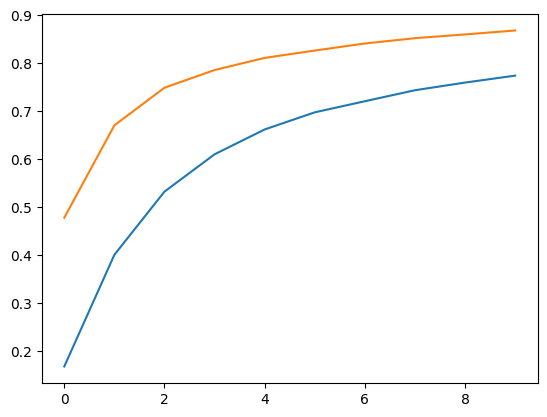

In [39]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

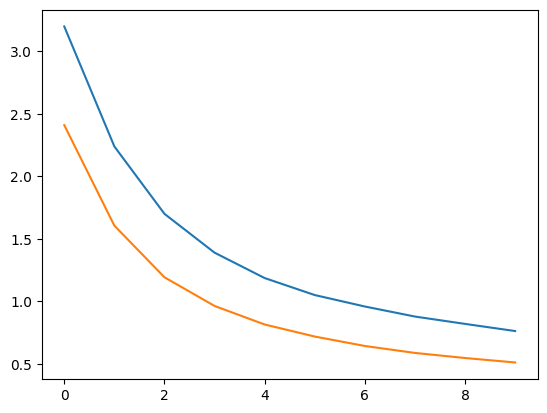

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [41]:
model.save("model.h5")